In [1]:
!pip install -q torch_snippets
from torch_snippets import *
from torchvision.datasets import MNIST
from torchvision import transforms
device = 'cuda' if torch.cuda.is_available() else 'cpu'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.3/110.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.2/226.2 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.7/158.7 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.9/397.9 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.6/470.6 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 68.3 MB/s eta 0:00:00


In [4]:
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
    transforms.Lambda(lambda x: x.to(device))
])

In [5]:
trn_ds = MNIST('/content/', transform=img_transform, train=True, download=True)
val_ds = MNIST('/content/', transform=img_transform, train=False, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 39.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.00MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.82MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.27MB/s]


In [6]:
batch_size = 256
trn_dl = DataLoader(trn_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

In [16]:
class AutoEncoder(nn.Module):
  def __init__(self, latent_dim):
    super().__init__()
    self.latent_dim = latent_dim
    self.encoder = nn.Sequential(
        nn.Linear(28 * 28, 128), nn.ReLU(True),
        nn.Linear(128, 64), nn.ReLU(True),
        #nn.Linear(64, 12), nn.ReLU(True),
        nn.Linear(64, latent_dim))
    self.decoder = nn.Sequential(
        #nn.Linear(latent_dim, 12), nn.ReLU(True),
        nn.Linear(latent_dim, 64), nn.ReLU(True),
        nn.Linear(64, 128), nn.ReLU(True),
        nn.Linear(128, 28 * 28), nn.Tanh())

  def forward(self, x):
    x = x.view(len(x), -1)
    x = self.encoder(x)
    x = self.decoder(x)
    x = x.view(len(x), 1, 28, 28)
    return x

In [17]:
def train_batch(input, model, criterion, optimizer):
  model.train()
  optimizer.zero_grad()
  output = model(input)
  loss = criterion(output, input)
  loss.backward()
  optimizer.step()
  return loss

@torch.no_grad()
def validate_batch(input, model, criterion):
  model.eval()
  output = model(input)
  loss = criterion(output, input)
  return loss

EPOCH: 1.000  val_loss: 0.197  trl_loss: 0.261  (18.72s - 74.89s remaining)
EPOCH: 2.000  val_loss: 0.165  trl_loss: 0.178  (37.03s - 55.54s remaining)
EPOCH: 3.000  val_loss: 0.154  trl_loss: 0.159  (55.16s - 36.77s remaining)
EPOCH: 4.000  val_loss: 0.150  trl_loss: 0.153  (74.34s - 18.58s remaining)
EPOCH: 5.000  val_loss: 0.146  trl_loss: 0.149  (92.61s - 0.00s remaining)


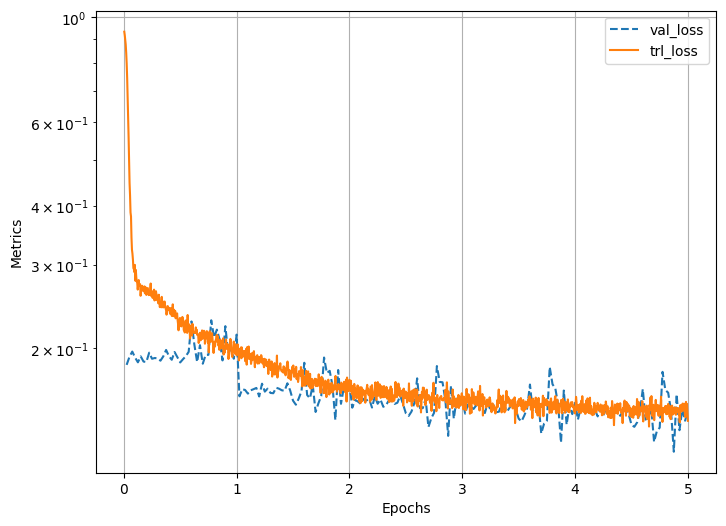

In [18]:
model = AutoEncoder(3).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

num_epochs = 5
log = Report(num_epochs)

for epoch in range(num_epochs):
  N = len(trn_dl)
  for ix, (data, _) in enumerate(trn_dl):
    loss = train_batch(data, model, criterion, optimizer)
    log.record(pos=(epoch + (ix+1)/N), trl_loss=loss, end='\r')

  N = len(val_dl)
  for ix, (data, _) in enumerate(val_dl):
    loss = validate_batch(data, model, criterion)
    log.record(pos=(epoch + (ix+1)/N), val_loss=loss, end='\r')
  log.report_avgs(epoch+1)
log.plot(log=True)

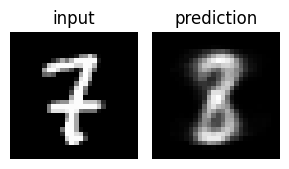

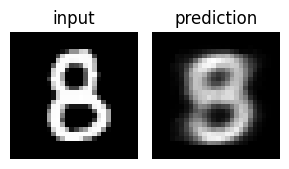

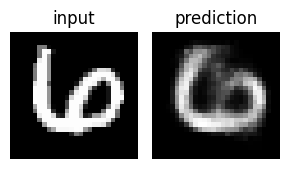

In [20]:
import matplotlib.pyplot as plt
for _ in range(3):
  ix = np.random.randint(len(val_ds))
  im, _ = val_ds[ix]
  _im = model(im[None])[0]
  fig, ax = plt.subplots(1,2,figsize=(3,3))
  show(im[0], ax=ax[0], title='input')
  show(_im[0], ax=ax[1], title='prediction')
  plt.tight_layout()
  plt.show()

EPOCH: 1.000  val_loss: 0.140  trn_loss: 0.243  (31.84s - 127.36s remaining)
EPOCH: 2.000  val_loss: 0.102  trn_loss: 0.118  (49.51s - 74.26s remaining)
EPOCH: 3.000  val_loss: 0.084  trn_loss: 0.093  (67.30s - 44.86s remaining)
EPOCH: 4.000  val_loss: 0.073  trn_loss: 0.080  (86.37s - 21.59s remaining)
EPOCH: 5.000  val_loss: 0.067  trn_loss: 0.072  (104.39s - 0.00s remaining)


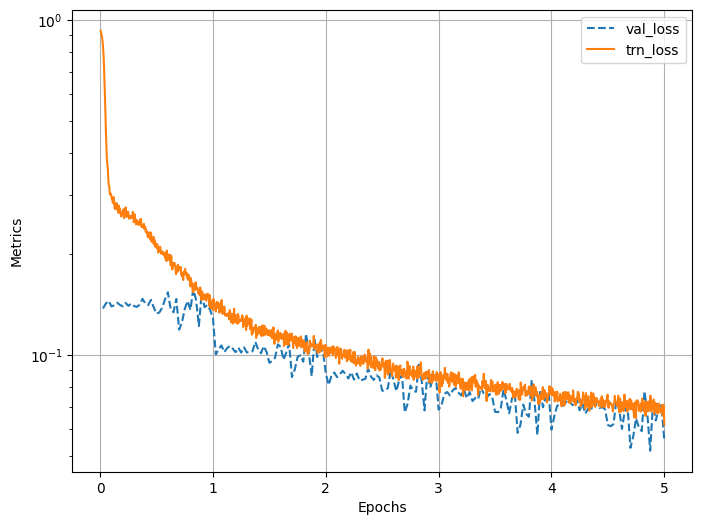

EPOCH: 1.000  val_loss: 0.216  trn_loss: 0.272  (19.31s - 77.23s remaining)
EPOCH: 2.000  val_loss: 0.194  trn_loss: 0.203  (37.28s - 55.92s remaining)
EPOCH: 3.000  val_loss: 0.183  trn_loss: 0.188  (54.95s - 36.64s remaining)
EPOCH: 4.000  val_loss: 0.178  trn_loss: 0.180  (73.99s - 18.50s remaining)
EPOCH: 5.000  val_loss: 0.174  trn_loss: 0.175  (92.13s - 0.00s remaining)


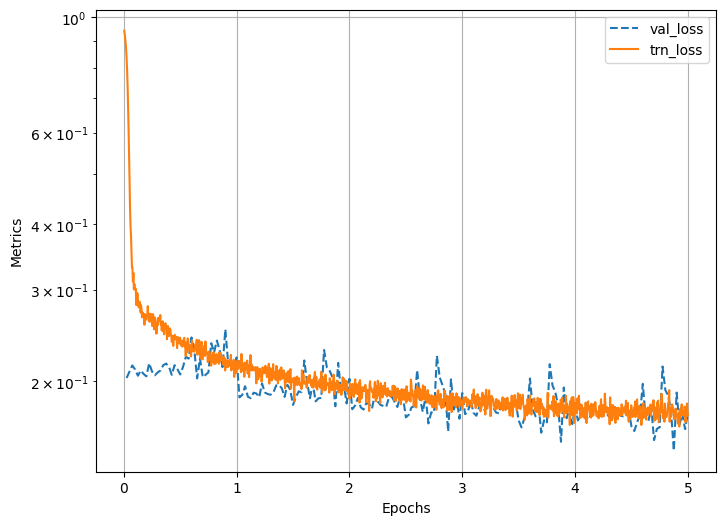

EPOCH: 1.000  val_loss: 0.194  trn_loss: 0.258  (17.50s - 69.99s remaining)
EPOCH: 2.000  val_loss: 0.169  trn_loss: 0.182  (37.62s - 56.44s remaining)
EPOCH: 3.000  val_loss: 0.160  trn_loss: 0.165  (55.18s - 36.78s remaining)
EPOCH: 4.000  val_loss: 0.154  trn_loss: 0.157  (73.82s - 18.45s remaining)
EPOCH: 5.000  val_loss: 0.150  trn_loss: 0.153  (92.09s - 0.00s remaining)


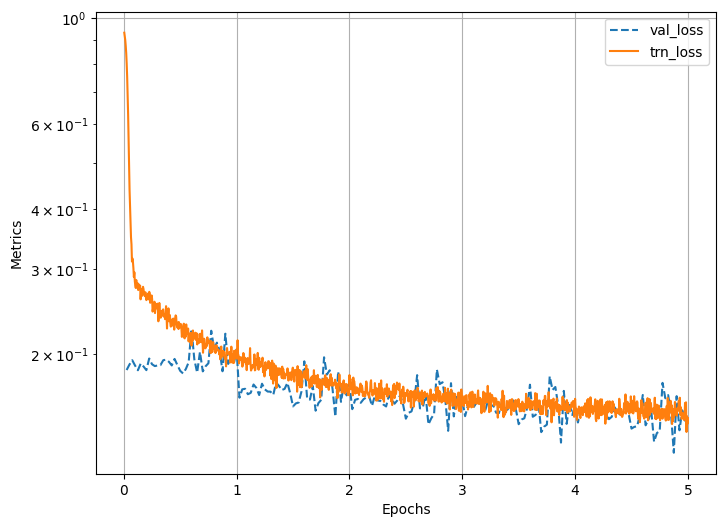

EPOCH: 1.000  val_loss: 0.165  trn_loss: 0.249  (17.46s - 69.85s remaining)
EPOCH: 2.000  val_loss: 0.138  trn_loss: 0.149  (36.19s - 54.28s remaining)
EPOCH: 3.000  val_loss: 0.128  trn_loss: 0.133  (54.02s - 36.01s remaining)
EPOCH: 4.000  val_loss: 0.122  trn_loss: 0.126  (72.02s - 18.00s remaining)
EPOCH: 5.000  val_loss: 0.118  trn_loss: 0.121  (90.98s - 0.00s remaining)


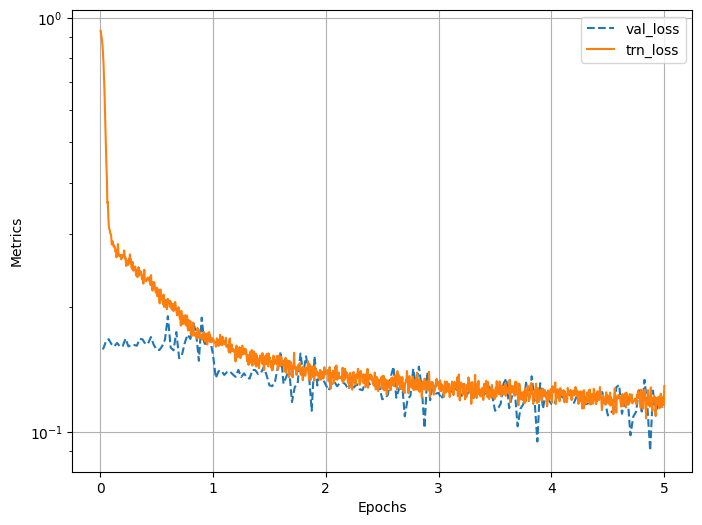

EPOCH: 1.000  val_loss: 0.149  trn_loss: 0.242  (17.58s - 70.34s remaining)
EPOCH: 2.000  val_loss: 0.113  trn_loss: 0.128  (35.32s - 52.98s remaining)
EPOCH: 3.000  val_loss: 0.101  trn_loss: 0.108  (54.19s - 36.12s remaining)
EPOCH: 4.000  val_loss: 0.095  trn_loss: 0.100  (72.39s - 18.10s remaining)
EPOCH: 5.000  val_loss: 0.091  trn_loss: 0.095  (91.45s - 0.00s remaining)


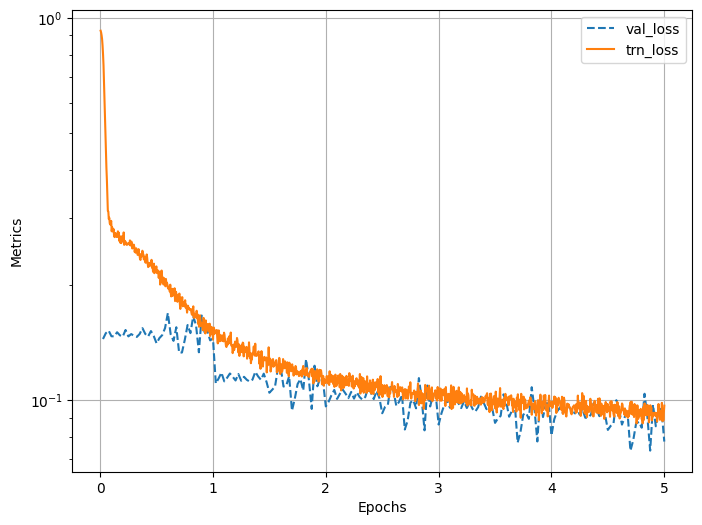

In [26]:
def train_aec(latent_dim):
  model = AutoEncoder(latent_dim).to(device)
  criterion = nn.MSELoss()
  optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

  num_epochs = 5
  log = Report(num_epochs)

  for epoch in range(num_epochs):
    N = len(trn_dl)
    for ix, (data, _) in enumerate(trn_dl):
      loss = train_batch(data, model, criterion, optimizer)
      log.record(pos=(epoch + (ix+1)/N), trn_loss=loss, end='\r')

    N = len(val_dl)
    for ix, (data, _) in enumerate(val_dl):
      loss = validate_batch(data, model, criterion)
      log.record(pos=(epoch + (ix+1)/N), val_loss=loss, end='\r')
    log.report_avgs(epoch+1)
  log.plot(log=True)
  return model

aecs = [train_aec(dim) for dim in [50, 2, 3, 5, 10]]

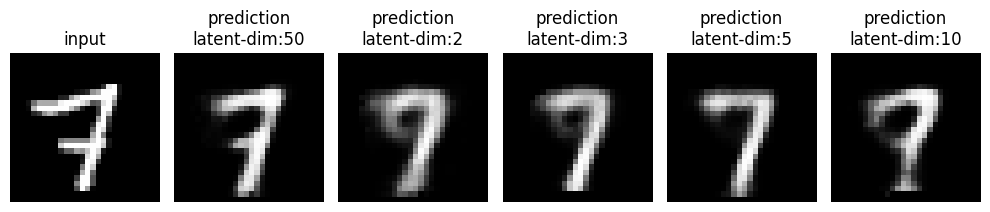

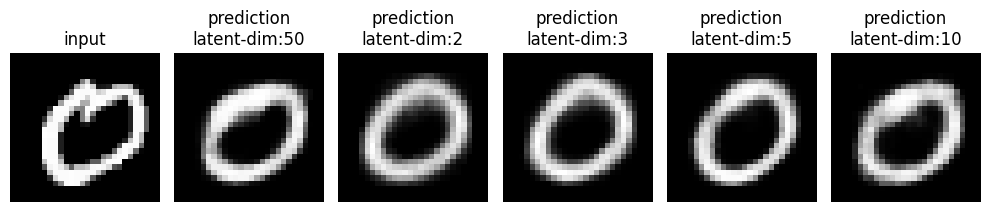

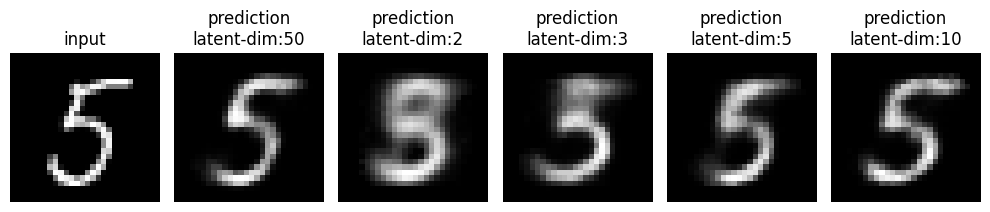

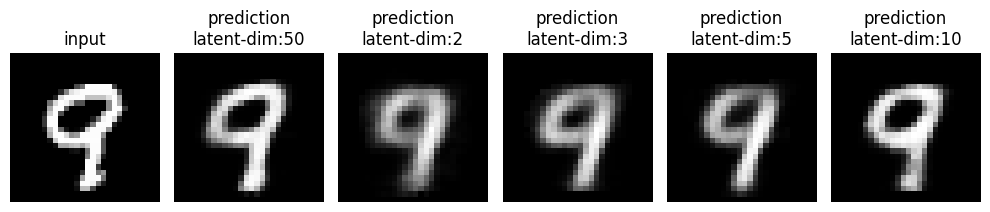

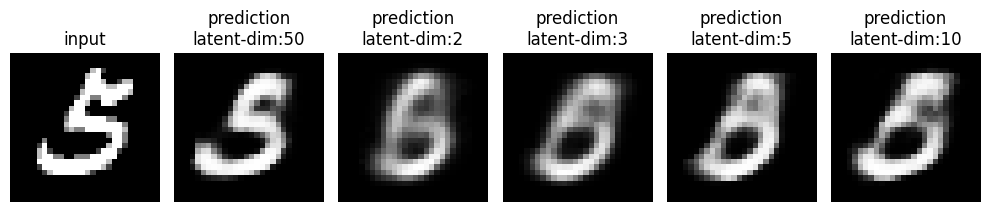

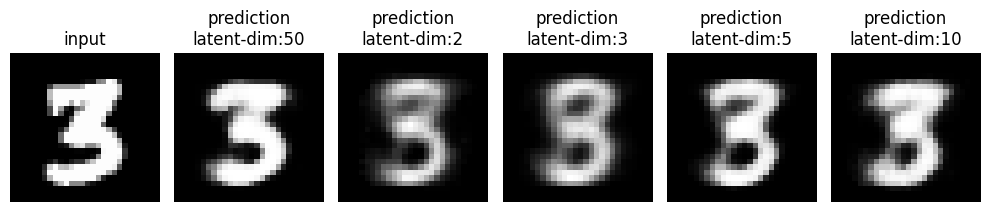

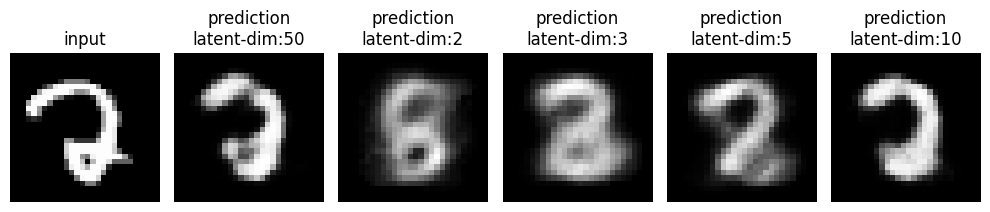

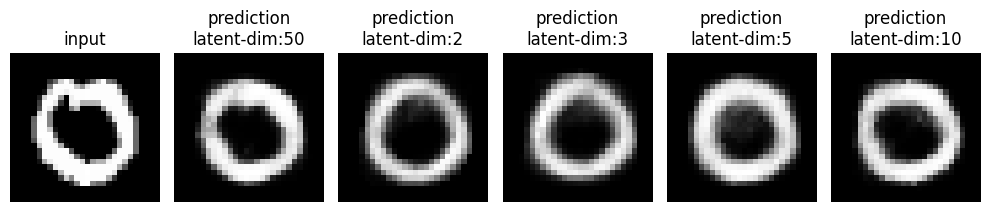

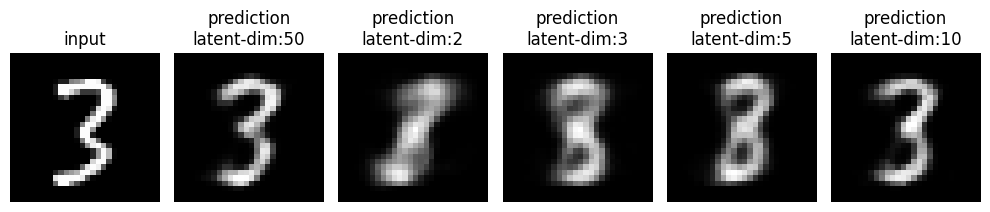

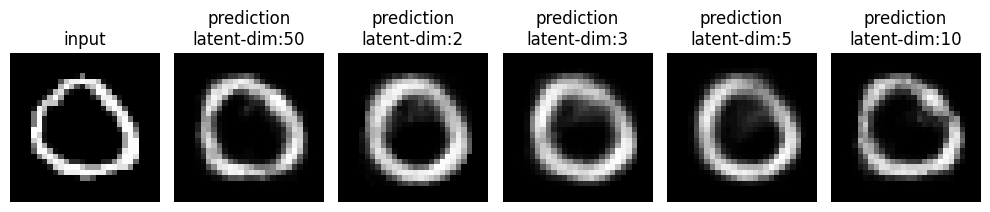

In [27]:
for _ in range(10):
  ix = np.random.randint(len(val_ds))
  im, _ = val_ds[ix]
  fig, ax = plt.subplots(1, len(aecs)+1, figsize=(10,4))
  ax = iter(ax.flat)
  show(im[0], ax=next(ax), title='input')
  for model in aecs:
    _im = model(im[None])[0]
    show(_im[0], ax=next(ax), title=f'prediction\nlatent-dim:{model.latent_dim}')
  plt.tight_layout()
  plt.show()